In [33]:
import pandas as pd
import numpy as np
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

In [34]:
#Memanggil dan deskripsi data set
used_car=pd.read_csv('toyota.csv')
print(used_car.head())

   model  year  price transmission  mileage fuelType  tax   mpg  engineSize
0   GT86  2016  16000       Manual    24089   Petrol  265  36.2         2.0
1   GT86  2017  15995       Manual    18615   Petrol  145  36.2         2.0
2   GT86  2015  13998       Manual    27469   Petrol  265  36.2         2.0
3   GT86  2017  18998       Manual    14736   Petrol  150  36.2         2.0
4   GT86  2017  17498       Manual    36284   Petrol  145  36.2         2.0


In [35]:
# Misalkan nilai tukar 1 GBP = 19000 IDR
exchange_rate = 19000
miles_to_km = 1.60934

# Mengubah kolom menjadi tipe data numerik dan menangani nilai yang tidak valid
used_car['price'] = pd.to_numeric(used_car['price'], errors='coerce')
used_car['mileage'] = pd.to_numeric(used_car['mileage'], errors='coerce')
used_car['tax'] = pd.to_numeric(used_car['tax'], errors='coerce')

# Mengisi nilai NaN dengan nilai default atau menghapus baris tersebut
used_car = used_car.fillna(0)

# Mengubah kolom price dari Pounds ke Rupiah
used_car['price'] = used_car['price'] * exchange_rate
# Mengubah kolom mileage dari Miles ke Kilometer
used_car['mileage'] = used_car['mileage'] * miles_to_km
# Mengubah kolom tax dari Pounds ke Rupiah
used_car['tax'] = used_car['tax'] * exchange_rate

# Menampilkan dataset yang telah diubah
used_car.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,GT86,2016,304000000,Manual,38767.39126,Petrol,5035000,36.2,2.0
1,GT86,2017,303905000,Manual,29957.86410,Petrol,2755000,36.2,2.0
2,GT86,2015,265962000,Manual,44206.96046,Petrol,5035000,36.2,2.0
3,GT86,2017,360962000,Manual,23715.23424,Petrol,2850000,36.2,2.0
4,GT86,2017,332462000,Manual,58393.29256,Petrol,2755000,36.2,2.0


In [36]:
# Label Encoding
label_encoder_model = LabelEncoder()
label_encoder_transmission = LabelEncoder()
label_encoder_fuelType = LabelEncoder()

used_car['model'] = label_encoder_model.fit_transform(used_car['model'])
used_car['transmission'] = label_encoder_transmission.fit_transform(used_car['transmission'])
used_car['fuelType'] = label_encoder_fuelType.fit_transform(used_car['fuelType'])

In [37]:
used_car.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6738 entries, 0 to 6737
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         6738 non-null   int32  
 1   year          6738 non-null   int64  
 2   price         6738 non-null   int64  
 3   transmission  6738 non-null   int32  
 4   mileage       6738 non-null   float64
 5   fuelType      6738 non-null   int32  
 6   tax           6738 non-null   int64  
 7   mpg           6738 non-null   float64
 8   engineSize    6738 non-null   float64
dtypes: float64(3), int32(3), int64(3)
memory usage: 394.9 KB


In [39]:
used_car.shape

(6738, 9)

<Axes: >

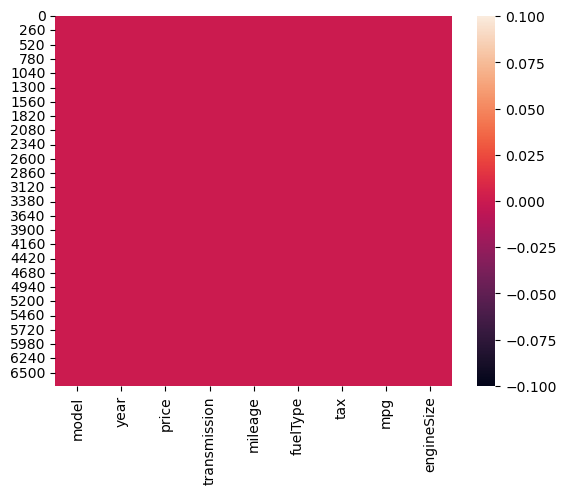

In [40]:
sns.heatmap(used_car.isnull())

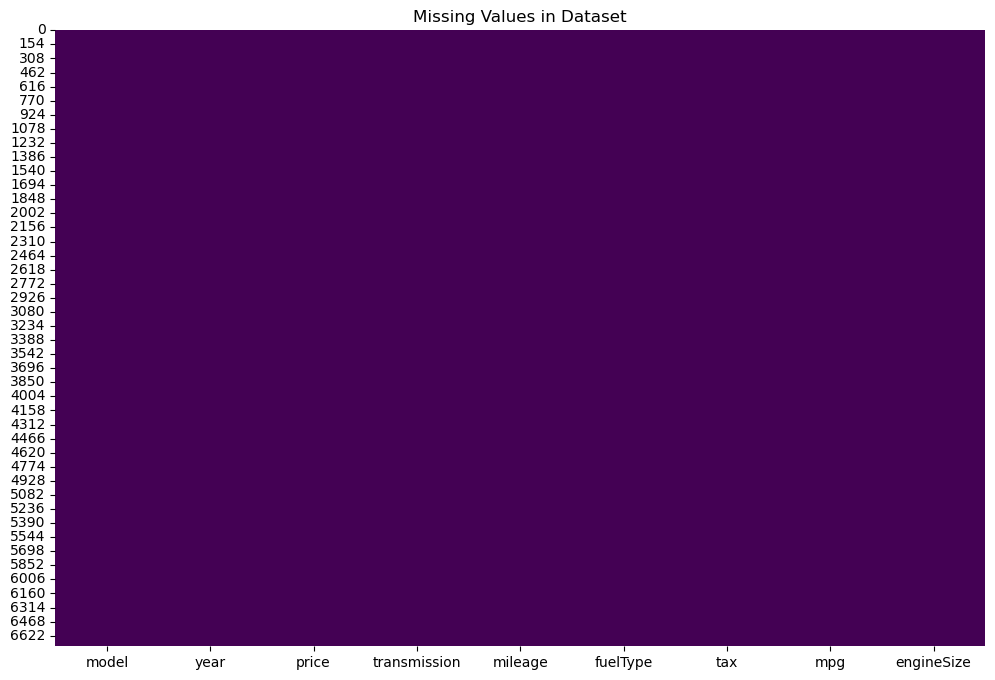

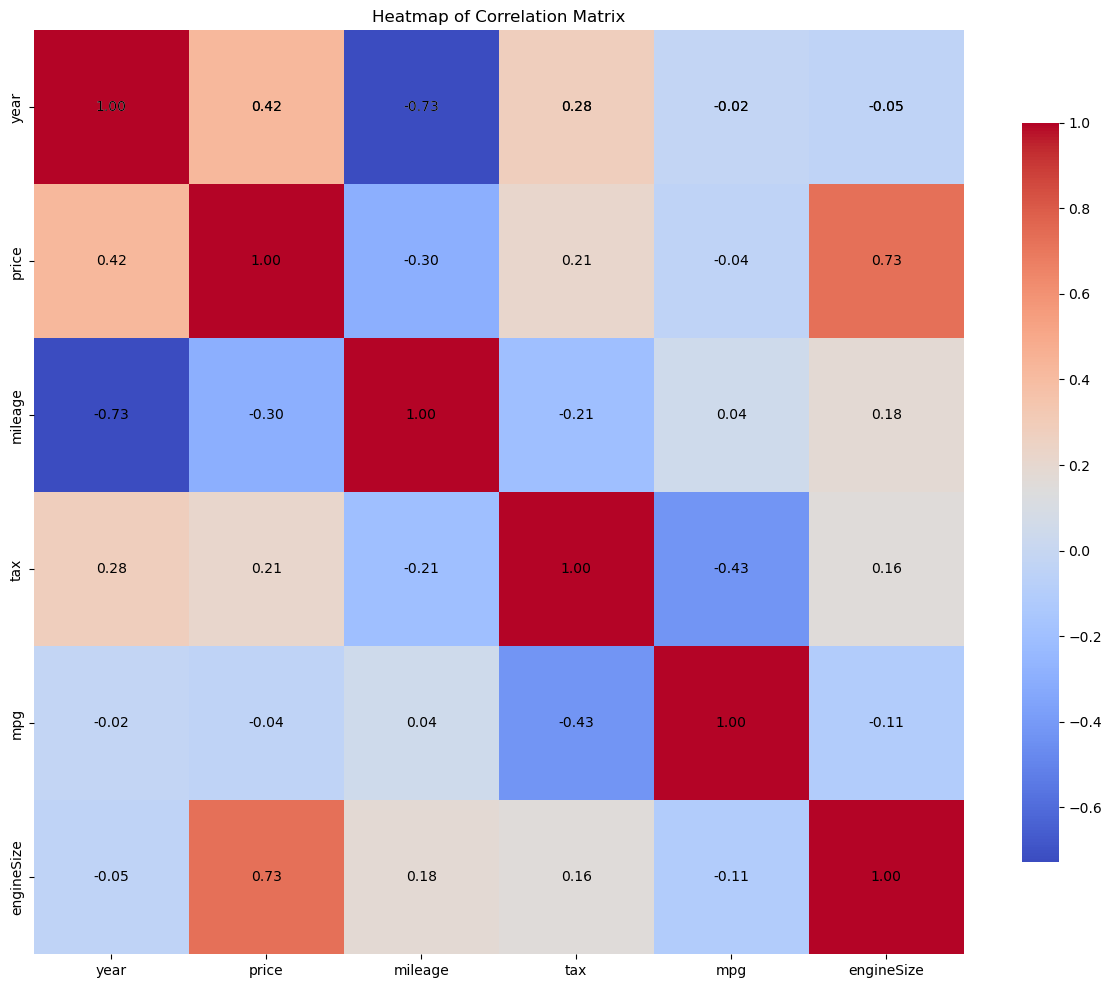

In [41]:
# Visualisasi missing values
plt.figure(figsize=(12, 8))
sns.heatmap(used_car.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values in Dataset")
plt.show()

# Mengambil kolom-kolom numerik saja
numerical_columns = used_car.select_dtypes(include=['float64', 'int64']).columns

# Menghapus kolom-kolom non-numerik
used_car_numerical = used_car[numerical_columns]

# Menghitung matriks korelasi
corr = used_car_numerical.corr()

# Membuat heatmap korelasi
plt.figure(figsize=(15, 12))
heatmap = sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', cbar_kws={'shrink': .8})

# Menambahkan anotasi manual untuk memastikan semua angka muncul dengan jelas
for i in range(len(corr)):
    for j in range(len(corr.columns)):
        plt.text(j + 0.5, i + 0.5, '{:.2f}'.format(corr.iloc[i, j]),
                 ha='center', va='center', color='black', fontsize=10)

plt.title("Heatmap of Correlation Matrix")
plt.show()

In [42]:
used_car.describe()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
count,6738.000000,6738.000000,6.738000e+03,6738.000000,6738.000000,6738.000000,6.738000e+03,6738.000000,6738.000000
mean,8.138617,2016.748145,2.379254e+08,0.681211,36785.350520,2.154052,1.799248e+06,63.042223,1.471297
std,6.939940,2.204062,1.205553e+08,0.666112,30779.374470,1.088492,1.403735e+06,15.836710,0.436159
min,0.000000,1998.000000,1.615000e+07,0.000000,3.218680,0.000000,0.000000e+00,2.800000,0.000000
25%,2.000000,2016.000000,1.575100e+08,0.000000,15201.825640,1.000000,0.000000e+00,55.400000,1.000000
50%,5.000000,2017.000000,2.051050e+08,1.000000,29793.711420,3.000000,2.565000e+06,62.800000,1.500000
75%,17.000000,2018.000000,2.849050e+08,1.000000,49992.135425,3.000000,2.755000e+06,69.000000,1.800000
max,17.000000,2020.000000,1.139905e+09,3.000000,280699.473460,3.000000,1.073500e+07,235.000000,4.500000


In [43]:
#Jumlah Mobil Bedasarkan Model
models = used_car.groupby('model').count()[['tax']].sort_values(by='tax',ascending=True).reset_index()
models = models.rename(columns={'tax':'numberOfCars'})

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17]),
 [Text(0, 0, '0'),
  Text(1, 0, '1'),
  Text(2, 0, '2'),
  Text(3, 0, '3'),
  Text(4, 0, '4'),
  Text(5, 0, '5'),
  Text(6, 0, '6'),
  Text(7, 0, '7'),
  Text(8, 0, '8'),
  Text(9, 0, '9'),
  Text(10, 0, '10'),
  Text(11, 0, '11'),
  Text(12, 0, '12'),
  Text(13, 0, '13'),
  Text(14, 0, '14'),
  Text(15, 0, '15'),
  Text(16, 0, '16'),
  Text(17, 0, '17')])

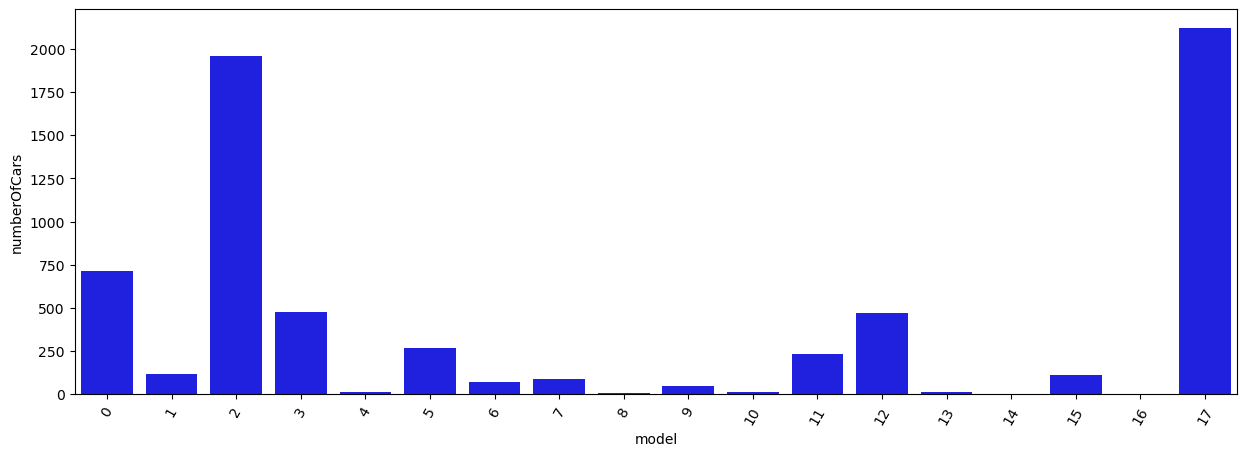

In [45]:
fig = plt.figure(figsize=(15,5))
sns.barplot(x=models['model'], y =models['numberOfCars'],color='blue')
plt.xticks(rotation=60)

In [46]:
# Ukuran Mesin
engine = used_car.groupby('engineSize').count()[['tax']].sort_values(by='tax').reset_index()
engine = engine.rename(columns={'tax':'count'})

<Axes: xlabel='engineSize', ylabel='count'>

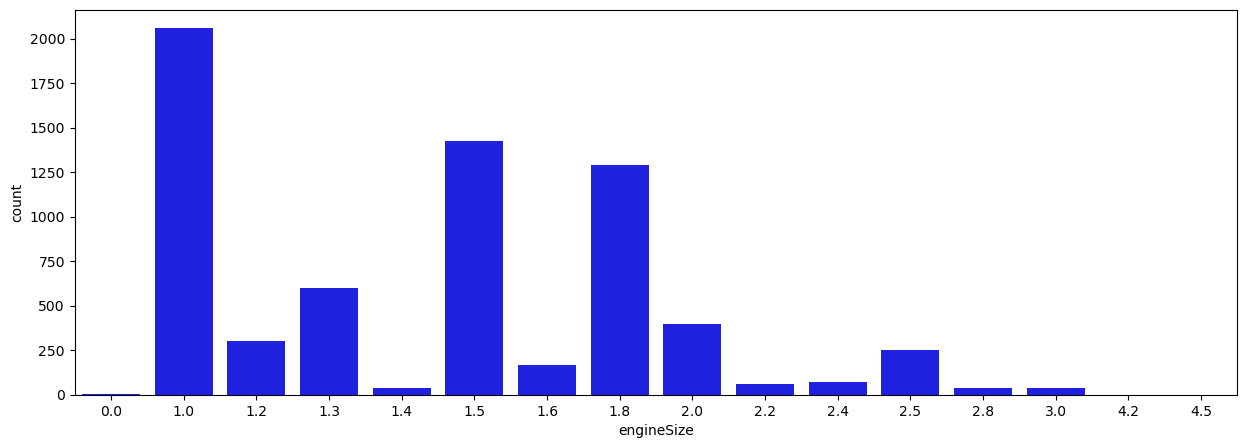

In [47]:
plt.figure(figsize=(15,5))
sns.barplot(x=engine['engineSize'], y =engine['count'],color='blue')

D:\ANACONDA\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


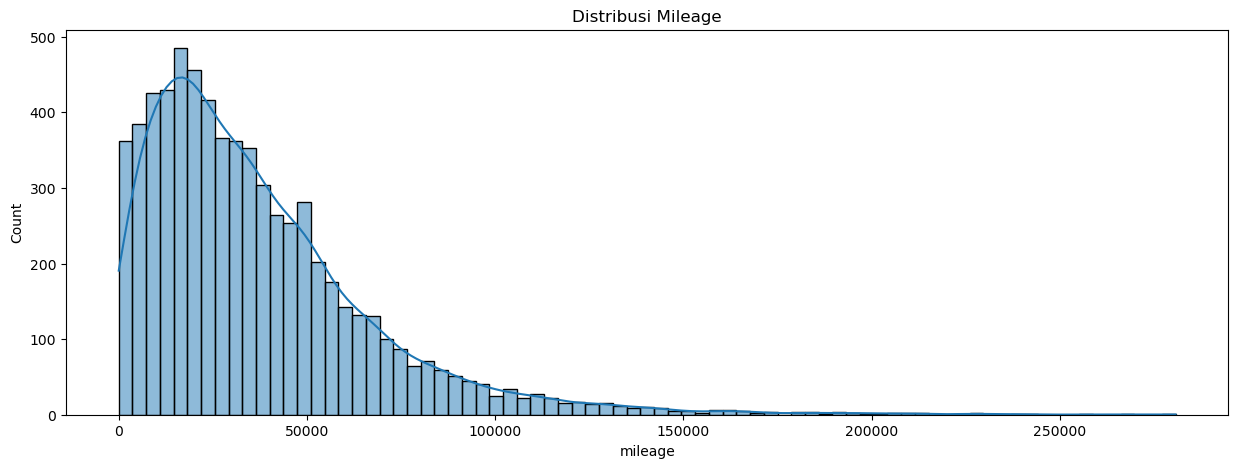

In [50]:
# Visualisasi distribusi mileage
plt.figure(figsize=(15, 5))
sns.histplot(used_car['mileage'], kde=True)
plt.title('Distribusi Mileage')
plt.show()

D:\ANACONDA\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


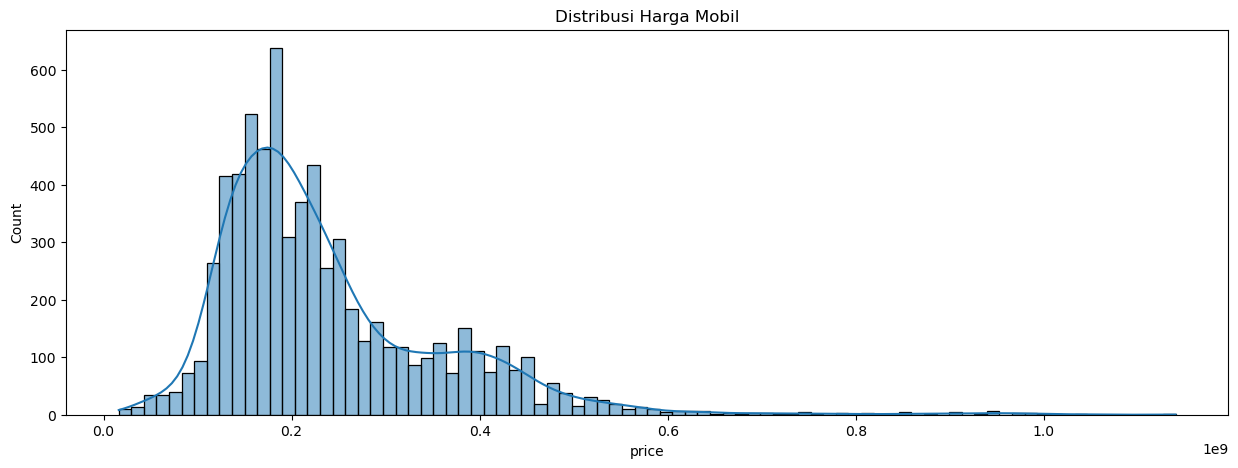

In [51]:
# Visualisasi distribusi harga mobil
plt.figure(figsize=(15, 5))
sns.histplot(used_car['price'], kde=True)
plt.title('Distribusi Harga Mobil')
plt.show()

In [54]:
# Memilih fitur dan target
features = ['model', 'year', 'mileage', 'tax', 'transmission', 'fuelType', 'mpg', 'engineSize']
X = used_car[features]
y = used_car['price']

In [55]:
# Split data training dan data testing
# Bagi data menjadi data latih dan data uji
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

# Melatih model Random Forest
rf = RandomForestRegressor(random_state=42)

# Fitting the model
rf.fit(X_train, y_train)

# Definisi grid parameter yang akan ditelusuri
param_grid = {
    'n_estimators': [100, 200, 300],  # Jumlah pohon keputusan dalam ensemble
    'max_depth': [None, 10, 20],  # Kedalaman maksimum setiap pohon
    'min_samples_split': [2, 5, 10],  # Jumlah sampel minimum yang diperlukan untuk membagi simpul internal
    'min_samples_leaf': [1, 2, 4]  # Jumlah sampel minimum yang diperlukan di setiap daun simpul
}

# Inisialisasi GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5)
grid_search.fit(X_train, y_train)

# Mendapatkan model terbaik
best_rf = grid_search.best_estimator_

# Prediksi dengan model terbaik
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

# Menghitung RMSE
train_rmse = mean_squared_error(y_train, y_train_pred, squared=False)
test_rmse = mean_squared_error(y_test, y_test_pred, squared=False)
test_r2 = r2_score(y_test, y_test_pred)
test_accuracy = test_r2 * 100

# Menampilkan hasil pengujian model dengan RMSE
print("Model Accuracy:")
print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print("Test R^2 Score:", test_accuracy, "%")

Model Accuracy:
Train RMSE: 16072622.584015956
Test RMSE: 23484670.87213795
Test R^2 Score: 96.40996881997161 %


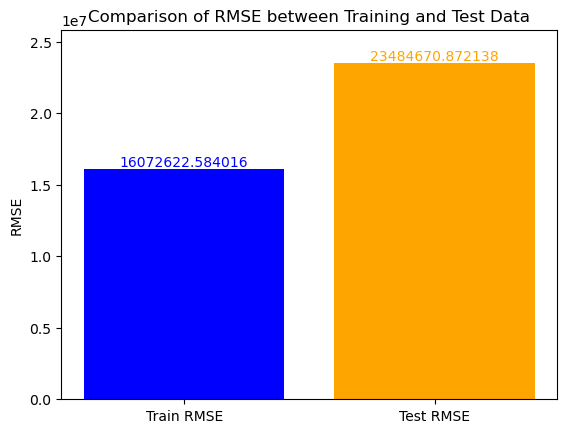

In [59]:
# Menyiapkan nilai error untuk plot
train_rmse = 16072622.584015956 # Nilai RMSE pelatihan
test_rmse = 23484670.87213795 # Nilai RMSE uji

# Membuat label untuk plot
labels = ['Train RMSE', 'Test RMSE']

# Membuat plot
plt.bar(['Train RMSE', 'Test RMSE'], [train_rmse, test_rmse], color=['blue', 'orange'])
plt.text(0, train_rmse + 0.001, f"{train_rmse:.6f}", ha='center', va='bottom', color='blue')
plt.text(1, test_rmse + 0.001, f"{test_rmse:.6f}", ha='center', va='bottom', color='orange')
plt.title('Comparison of RMSE between Training and Test Data')
plt.ylabel('RMSE')
plt.ylim(0, max(train_rmse, test_rmse) * 1.1)
plt.show()

In [60]:
# Menyimpan model terbaik
with open('best_random_forest_model.sav', 'wb') as f:
    pickle.dump(best_rf, f)

In [61]:
# Menyimpan mapping ke file
with open('model_mapping.pkl', 'wb') as file:
    pickle.dump(label_encoder_model, file)
with open('transmission_mapping.pkl', 'wb') as file:
    pickle.dump(label_encoder_transmission, file)
with open('fuelType_mapping.pkl', 'wb') as file:
    pickle.dump(label_encoder_fuelType, file)